# PCA, reducción de dimensionalidad y selección de características

Este notebook explica de forma práctica:

- qué significa **reducción de dimensionalidad**,
- qué hace **PCA** y cuándo usarlo,
- cómo interpretar componentes principales,
- la diferencia entre **transformar variables** y **seleccionar variables**,
- y varios métodos comunes de **feature selection** en `scikit-learn`.

La idea es que este material sirva tanto para clase como para autoestudio.

## 1. Objetivo general

Cuando trabajamos con muchas variables, aparecen problemas frecuentes:

- más ruido,
- más colinealidad,
- modelos más difíciles de interpretar,
- mayor costo computacional,
- y riesgo de sobreajuste.

Para enfrentar esto, suelen usarse dos estrategias:

### A. Reducción de dimensionalidad
Crea **nuevas variables** a partir de las originales.

Ejemplo:
- Tengo 20 variables originales.
- Las transformo en 3 componentes nuevas.

**PCA** pertenece a esta familia.

### B. Selección de características
Elige un subconjunto de las variables originales.

Ejemplo:
- Tengo 20 variables originales.
- Me quedo con 6 variables importantes y descarto el resto.

Ambas buscan simplificar el problema, pero no hacen lo mismo.

## 2. Diferencia clave: PCA vs selección de variables

### PCA
- No conserva necesariamente las variables originales.
- Construye combinaciones lineales de ellas.
- Suele ayudar a comprimir información.

### Selección de características
- Mantiene variables originales.
- Busca identificar cuáles aportan más señal.
- Suele ser más fácil de explicar a negocio o a un profesor.

Regla práctica:

- Si tu prioridad es **compresión, visualización o eliminar colinealidad**, PCA puede ayudar.
- Si tu prioridad es **interpretabilidad**, suele convenir feature selection.

## 3. Dataset de ejemplo

Vamos a usar el dataset **Wine** de `scikit-learn`, que tiene:

- 178 observaciones
- 13 variables numéricas
- 3 clases de vino

Es útil porque:
- tiene varias variables continuas,
- permite clasificación,
- y es suficientemente pequeño para explicar todo con claridad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

print("Forma de X:", X.shape)
print("Clases:", np.unique(y))
X.head()

Forma de X: (178, 13)
Clases: [0 1 2]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 4. Inspección inicial

Antes de aplicar PCA o selección de variables, conviene revisar:

- tamaño del dataset,
- tipos de datos,
- escalas,
- correlaciones,
- y posible redundancia entre variables.

In [3]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [4]:
corr = X.corr().round(2)
corr.iloc[:8, :8]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols
alcohol,1.00,0.09,0.21,-0.31,0.27,0.29,0.24,-0.16
malic_acid,0.09,1.00,0.16,0.29,-0.05,-0.34,-0.41,0.29
ash,0.21,0.16,1.00,0.44,0.29,0.13,0.12,0.19
alcalinity_of_ash,-0.31,0.29,0.44,1.00,-0.08,-0.32,-0.35,0.36
magnesium,0.27,-0.05,0.29,-0.08,1.00,0.21,0.20,-0.26
total_phenols,0.29,-0.34,0.13,-0.32,0.21,1.00,0.86,-0.45
flavanoids,0.24,-0.41,0.12,-0.35,0.20,0.86,1.00,-0.54
nonflavanoid_phenols,-0.16,0.29,0.19,0.36,-0.26,-0.45,-0.54,1.00


## 5. ¿Por qué escalar antes de PCA?

**PCA depende de la varianza** de cada variable.

Si una variable está en una escala mucho más grande que otra, puede dominar el resultado, aunque no sea la más informativa.

Por eso, antes de PCA normalmente usamos `StandardScaler`:

- resta la media,
- divide por la desviación estándar,
- deja cada variable con media 0 y varianza 1.

En feature selection, escalar no siempre es obligatorio, pero en PCA casi siempre sí.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:3]

array([[ 1.51861254, -0.5622498 ,  0.23205254, -1.16959318,  1.91390522,
         0.80899739,  1.03481896, -0.65956311,  1.22488398,  0.25171685,
         0.36217728,  1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, -2.49084714,  0.01814502,
         0.56864766,  0.73362894, -0.82071924, -0.54472099, -0.29332133,
         0.40605066,  1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, -0.2687382 ,  0.08835836,
         0.80899739,  1.21553297, -0.49840699,  2.13596773,  0.26901965,
         0.31830389,  0.78858745,  1.39514818]])

## 6. Intuición de PCA

PCA busca nuevas direcciones en los datos:

- **PC1**: la dirección con mayor varianza posible,
- **PC2**: la siguiente dirección con mayor varianza, ortogonal a PC1,
- **PC3**: la siguiente, ortogonal a las anteriores,
- y así sucesivamente.

Cada componente principal es una combinación lineal de las variables originales.

Ejemplo conceptual:

\[
PC1 = 0.4 x_1 + 0.2 x_2 - 0.5 x_3 + ...
\]

Eso significa que PCA no "elige" variables; las **mezcla**.

## 7. Ajustar PCA completo

Primero ajustamos PCA con todas las componentes para entender cuánta varianza explica cada una.

In [6]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_var = pd.DataFrame({
    "componente": [f"PC{i}" for i in range(1, len(pca_full.explained_variance_ratio_) + 1)],
    "varianza_explicada": pca_full.explained_variance_ratio_,
    "varianza_acumulada": np.cumsum(pca_full.explained_variance_ratio_)
})

explained_var

,componente,varianza_explicada,varianza_acumulada
0,PC1,0.361988,0.361988
1,PC2,0.192075,0.554063
2,PC3,0.111236,0.665300
3,PC4,0.070690,0.735990
4,PC5,0.065633,0.801623
5,PC6,0.049358,0.850981
6,PC7,0.042387,0.893368
7,PC8,0.026807,0.920175
8,PC9,0.022222,0.942397
9,PC10,0.019300,0.961697


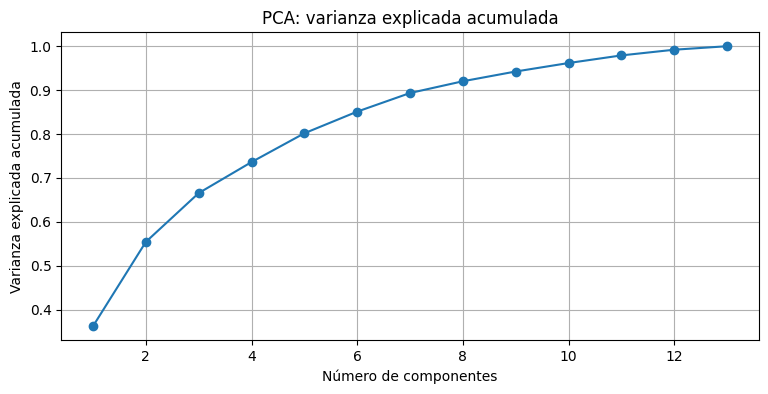

In [7]:
plt.figure(figsize=(9, 4))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    np.cumsum(pca_full.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA: varianza explicada acumulada")
plt.grid(True)
plt.show()

## 8. ¿Cuántas componentes elegir?

No existe una sola regla perfecta, pero algunas prácticas comunes son:

- elegir el número mínimo de componentes que explique **80%**, **90%** o **95%** de la varianza,
- mirar el **codo** del gráfico,
- o validar el desempeño del modelo downstream.

Aquí vamos a calcular cuántas componentes se necesitan para distintos umbrales.

In [8]:
thresholds = [0.80, 0.90, 0.95]

rows = []
cum = np.cumsum(pca_full.explained_variance_ratio_)

for t in thresholds:
    n_comp = np.argmax(cum >= t) + 1
    rows.append({
        "umbral_varianza": t,
        "n_componentes": n_comp
    })

pd.DataFrame(rows)

,umbral_varianza,n_componentes
0,0.80,5
1,0.90,8
2,0.95,10


## 9. PCA con 2 componentes para visualización

Aunque 2 componentes no siempre bastan para modelar, sí son muy útiles para **visualizar**.

In [9]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_df["target"] = y.values

pca_df.head()

,PC1,PC2,target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


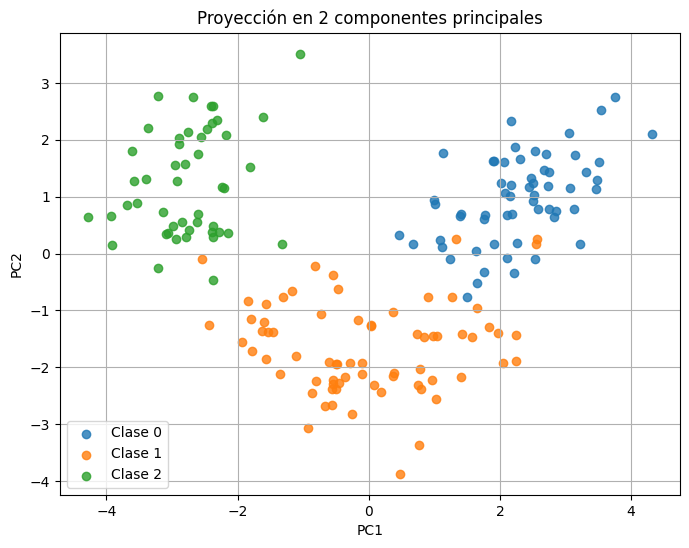

In [10]:
plt.figure(figsize=(8, 6))

for cls in sorted(pca_df["target"].unique()):
    subset = pca_df[pca_df["target"] == cls]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Clase {cls}", alpha=0.8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección en 2 componentes principales")
plt.legend()
plt.grid(True)
plt.show()

## 10. Interpretación de cargas (loadings)

Las **cargas** indican cuánto pesa cada variable original dentro de cada componente principal.

Eso ayuda a responder:

- ¿qué variables empujan más a PC1?
- ¿qué variables dominan PC2?

Ojo: una carga alta, positiva o negativa, indica que esa variable contribuye bastante a esa componente.

In [11]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=X.columns,
    columns=["PC1", "PC2"]
).sort_values("PC1", key=np.abs, ascending=False)

loadings

,PC1,PC2
flavanoids,0.422934,-0.003360
total_phenols,0.394661,0.065040
od280/od315_of_diluted_wines,0.376167,-0.164496
proanthocyanins,0.313429,0.039302
nonflavanoid_phenols,-0.298533,0.028779
hue,0.296715,-0.279235
proline,0.286752,0.364903
malic_acid,-0.245188,0.224931
alcalinity_of_ash,-0.239320,-0.010591
alcohol,0.144329,0.483652


In [12]:
loadings.abs().sort_values("PC1", ascending=False).head(8)

,PC1,PC2
flavanoids,0.422934,0.003360
total_phenols,0.394661,0.065040
od280/od315_of_diluted_wines,0.376167,0.164496
proanthocyanins,0.313429,0.039302
nonflavanoid_phenols,0.298533,0.028779
hue,0.296715,0.279235
proline,0.286752,0.364903
malic_acid,0.245188,0.224931


## 11. Ventajas y limitaciones de PCA

### Ventajas
- reduce dimensión,
- elimina parte de la redundancia,
- ayuda con colinealidad,
- puede mejorar eficiencia,
- es útil para visualización.

### Limitaciones
- pierde interpretabilidad,
- las componentes no son variables "naturales",
- no usa la variable objetivo en su versión clásica,
- puede comprimir ruido si se usa mal,
- una alta varianza no siempre equivale a alta capacidad predictiva.

Muy importante: PCA es **no supervisado**.  
Eso significa que construye componentes sin mirar `y`.

## 12. PCA en un flujo de modelado

Ahora vamos a comparar un modelo base vs un modelo con PCA.

Usaremos regresión logística y validación cruzada.

In [13]:
pipe_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

scores_base = cross_val_score(pipe_base, X, y, cv=5, scoring="accuracy")
print("Accuracy base por fold:", np.round(scores_base, 4))
print("Accuracy promedio base:", scores_base.mean().round(4))

Accuracy base por fold: [0.9722 0.9722 1.     0.9714 1.    ]
Accuracy promedio base: 0.9832


In [15]:
pipe_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("model", LogisticRegression(max_iter=5000))
])

scores_pca = cross_val_score(pipe_pca, X, y, cv=5, scoring="accuracy")
print("Accuracy con PCA por fold:", np.round(scores_pca, 4))
print("Accuracy promedio con PCA:", scores_pca.mean().round(4))

Accuracy con PCA por fold: [0.9444 0.9722 1.     0.9714 1.    ]
Accuracy promedio con PCA: 0.9776


## 13. Interpretación del resultado

Si PCA mantiene un desempeño similar con menos dimensiones, puede ser útil porque:

- simplifica el problema,
- reduce ruido o colinealidad,
- y acelera algunos modelos.

Pero si el desempeño cae mucho, quizá la compresión fue excesiva.

La decisión no debe tomarse solo por teoría; conviene **validarla empíricamente**.

# 14. Selección de características

Ahora pasamos a la otra gran estrategia: **feature selection**.

La idea ya no es crear variables nuevas, sino **escoger algunas de las originales**.

Hay tres familias comunes:

1. **Filter methods**
2. **Wrapper methods**
3. **Embedded methods**

## 15. Método 1: Filter methods

Los filtros evalúan cada variable usando una medida estadística, sin entrenar un modelo complejo sobre subsets iterativos.

Ejemplos:
- correlación,
- chi-cuadrado,
- ANOVA F-test,
- mutual information.

Ventajas:
- rápidos,
- fáciles de aplicar,
- buenos como primer tamiz.

Limitación:
- suelen evaluar variables de manera más "individual", sin capturar toda la interacción entre ellas.

In [16]:
selector_kbest = SelectKBest(score_func=f_classif, k=5)
selector_kbest.fit(X, y)

kbest_scores = pd.DataFrame({
    "feature": X.columns,
    "score_f": selector_kbest.scores_
}).sort_values("score_f", ascending=False)

kbest_scores

,feature,score_f
6,flavanoids,233.925873
12,proline,207.920374
11,od280/od315_of_diluted_wines,189.972321
0,alcohol,135.077624
9,color_intensity,120.664018
10,hue,101.316795
5,total_phenols,93.733010
1,malic_acid,36.943425
3,alcalinity_of_ash,35.771637
8,proanthocyanins,30.271383


In [17]:
selected_kbest = X.columns[selector_kbest.get_support()].tolist()
selected_kbest

['alcohol',
 'flavanoids',
 'color_intensity',
 'od280/od315_of_diluted_wines',
 'proline']

## 16. Modelo usando variables seleccionadas por filtro

In [18]:
X_kbest = X[selected_kbest]

pipe_kbest = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

scores_kbest = cross_val_score(pipe_kbest, X_kbest, y, cv=5, scoring="accuracy")
print("Accuracy con SelectKBest:", scores_kbest.mean().round(4))

Accuracy con SelectKBest: 0.961


## 17. Método 2: Wrapper methods

Los wrapper methods prueban subconjuntos de variables usando el desempeño de un modelo como criterio.

Ejemplos:
- forward selection,
- backward elimination,
- RFE (Recursive Feature Elimination).

Ventaja:
- consideran la utilidad de variables dentro de un modelo.

Desventaja:
- pueden ser más costosos computacionalmente.

In [19]:
rfe_model = LogisticRegression(max_iter=5000)
rfe = RFE(estimator=rfe_model, n_features_to_select=5)

rfe.fit(X_scaled, y)

rfe_results = pd.DataFrame({
    "feature": X.columns,
    "seleccionada": rfe.support_,
    "ranking": rfe.ranking_
}).sort_values(["ranking", "feature"])

rfe_results

,feature,seleccionada,ranking
0,alcohol,True,1
9,color_intensity,True,1
6,flavanoids,True,1
10,hue,True,1
12,proline,True,1
11,od280/od315_of_diluted_wines,False,2
2,ash,False,3
3,alcalinity_of_ash,False,4
8,proanthocyanins,False,5
1,malic_acid,False,6


In [20]:
selected_rfe = X.columns[rfe.support_].tolist()
selected_rfe

['alcohol', 'flavanoids', 'color_intensity', 'hue', 'proline']

In [21]:
X_rfe = X[selected_rfe]

pipe_rfe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

scores_rfe = cross_val_score(pipe_rfe, X_rfe, y, cv=5, scoring="accuracy")
print("Accuracy con RFE:", scores_rfe.mean().round(4))

Accuracy con RFE: 0.9776


## 18. Método 3: Embedded methods

Estos métodos seleccionan variables durante el entrenamiento del modelo.

Ejemplos:
- Lasso / Elastic Net
- árboles y random forest
- gradient boosting

Ventaja:
- suelen ser prácticos y potentes.

Desventaja:
- la importancia depende del modelo elegido.

### 18.1 Embedded con Lasso

Lasso es más natural en regresión, pero aquí lo usamos con el target numérico codificado para mostrar la lógica de selección.

La idea importante es esta:
- si el coeficiente tiende a 0, la variable aporta poco bajo esa penalización.

In [22]:
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42))
])

lasso_pipe.fit(X, y)

lasso = lasso_pipe.named_steps["lasso"]

lasso_results = pd.DataFrame({
    "feature": X.columns,
    "coef_lasso": lasso.coef_,
    "abs_coef_lasso": np.abs(lasso.coef_)
}).sort_values("abs_coef_lasso", ascending=False)

lasso_results

,feature,coef_lasso,abs_coef_lasso
6,flavanoids,-0.325467,0.325467
12,proline,-0.219113,0.219113
11,od280/od315_of_diluted_wines,-0.181295,0.181295
9,color_intensity,0.164435,0.164435
3,alcalinity_of_ash,0.124900,0.124900
0,alcohol,-0.083482,0.083482
5,total_phenols,0.045017,0.045017
10,hue,-0.042192,0.042192
2,ash,-0.035540,0.035540
1,malic_acid,0.026402,0.026402


### 18.2 Embedded con Random Forest

Los árboles permiten obtener importancias de variables basadas en la reducción de impureza.

In [23]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X, y)

rf_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

rf_importances

,feature,importance
6,flavanoids,0.180601
12,proline,0.162279
9,color_intensity,0.160890
0,alcohol,0.128887
11,od280/od315_of_diluted_wines,0.104100
10,hue,0.080984
5,total_phenols,0.050374
3,alcalinity_of_ash,0.030657
4,magnesium,0.029036
1,malic_acid,0.028152


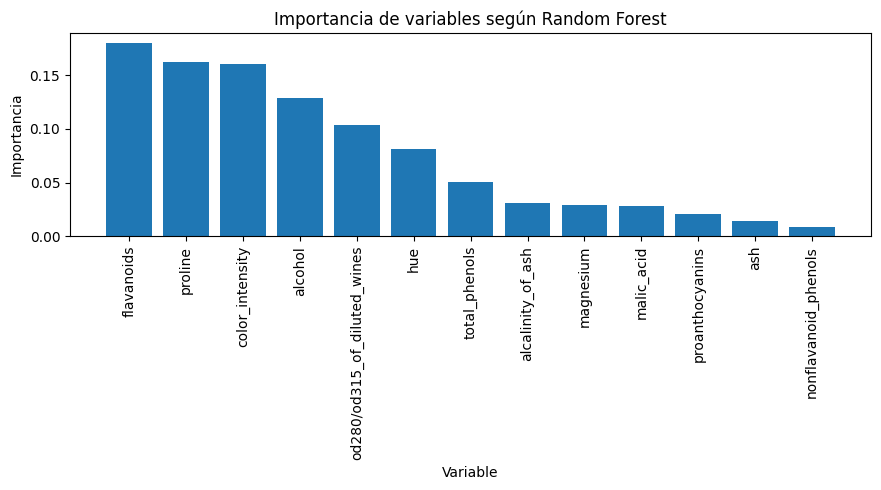

In [24]:
plt.figure(figsize=(9, 5))
plt.bar(rf_importances["feature"], rf_importances["importance"])
plt.xticks(rotation=90)
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.title("Importancia de variables según Random Forest")
plt.tight_layout()
plt.show()

## 19. Comparación resumida de métodos

Vamos a comparar qué variables aparecen arriba en distintos enfoques.

In [25]:
summary_selection = pd.DataFrame({"feature": X.columns})

summary_selection["kbest_top5"] = summary_selection["feature"].isin(selected_kbest)
summary_selection["rfe_top5"] = summary_selection["feature"].isin(selected_rfe)

top5_lasso = lasso_results.head(5)["feature"].tolist()
top5_rf = rf_importances.head(5)["feature"].tolist()

summary_selection["lasso_top5"] = summary_selection["feature"].isin(top5_lasso)
summary_selection["rf_top5"] = summary_selection["feature"].isin(top5_rf)

summary_selection

,feature,kbest_top5,rfe_top5,lasso_top5,rf_top5
0,alcohol,True,True,False,True
1,malic_acid,False,False,False,False
2,ash,False,False,False,False
3,alcalinity_of_ash,False,False,True,False
4,magnesium,False,False,False,False
5,total_phenols,False,False,False,False
6,flavanoids,True,True,True,True
7,nonflavanoid_phenols,False,False,False,False
8,proanthocyanins,False,False,False,False
9,color_intensity,True,True,True,True


## 20. ¿Qué método elegir?

No hay un único ganador universal.

### Usa PCA cuando:
- quieres comprimir variables,
- tienes mucha colinealidad,
- quieres visualización,
- te importa menos la interpretabilidad directa.

### Usa feature selection cuando:
- quieres mantener variables originales,
- necesitas explicar el modelo,
- quieres reducir ruido conservando significado de negocio,
- estás construyendo un pipeline supervisado.

### Muchas veces conviene:
- comparar varias alternativas,
- y elegir con validación cruzada y criterio de negocio.

## 21. Experimento comparativo simple

Vamos a comparar cuatro escenarios:

1. todas las variables,
2. PCA con 5 componentes,
3. top 5 por SelectKBest,
4. top 5 por RFE.

In [26]:
comparison = pd.DataFrame({
    "escenario": [
        "Todas las variables",
        "PCA (5 componentes)",
        "SelectKBest (top 5)",
        "RFE (top 5)"
    ],
    "accuracy_cv_promedio": [
        scores_base.mean(),
        scores_pca.mean(),
        scores_kbest.mean(),
        scores_rfe.mean()
    ]
}).sort_values("accuracy_cv_promedio", ascending=False)

comparison

,escenario,accuracy_cv_promedio
0,Todas las variables,0.983175
1,PCA (5 componentes),0.977619
3,RFE (top 5),0.977619
2,SelectKBest (top 5),0.960952


## 22. Ideas importantes para no confundirse

1. **Menos variables no siempre significa mejor modelo**.
2. **Más varianza explicada no siempre significa mejor predicción**.
3. **PCA no selecciona variables; las transforma**.
4. **La selección de variables depende del método y del modelo**.
5. **Siempre valida con datos fuera de muestra**.

## 23. Recomendaciones prácticas

### En proyectos reales:
- empieza con EDA y correlaciones,
- escala antes de PCA,
- evita hacer PCA fuera del pipeline de validación,
- compara desempeño base vs PCA vs feature selection,
- prioriza interpretabilidad cuando negocio lo exija.

### Error frecuente:
hacer PCA sobre todo el dataset antes de separar train/test.  
Eso introduce fuga de información.  
La transformación debe aprenderse solo en entrenamiento.

## 24. Conclusión final

- **Reducción de dimensionalidad** busca representar los datos con menos dimensiones.
- **PCA** es el método clásico: útil para compresión, visualización y colinealidad.
- **Selección de características** busca conservar solo variables originales relevantes.
- No son sustitutos perfectos entre sí.
- La mejor elección depende de:
  - objetivo del problema,
  - necesidad de interpretación,
  - desempeño predictivo,
  - y contexto del negocio.